# Actividad 3.4: Visualización Exploratoria

**Objetivos:**
- Cargar y volver a limpiar el dataset.
- Crear un directorio para almacenar visualizaciones.
- Generar e interpretar: un histograma, un gráfico de barras, un diagrama de dispersión y un mapa de calor.
- Guardar las imágenes generadas en la carpeta `../visualizations`.

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create the directory for visualizations if it doesn't exist
output_dir = "../visualizations"
os.makedirs(output_dir, exist_ok=True)

# 1. Load and clean the dataset
df = pd.read_csv("titanic.csv")

# Standardize columns
df.columns = df.columns.str.lower().str.strip()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
if "cabin" in df.columns:
    df.drop("cabin", axis=1, inplace=True)

# Convert types
df["age"] = df["age"].astype(int)

# Set seaborn style for better aesthetics
sns.set_theme(style="whitegrid")
print("Data cleaned and ready for visualization!")

Data cleaned and ready for visualization!


### 1. Histograma de una variable numérica
Visualizaremos la distribución de la edad (`age`) de los pasajeros.

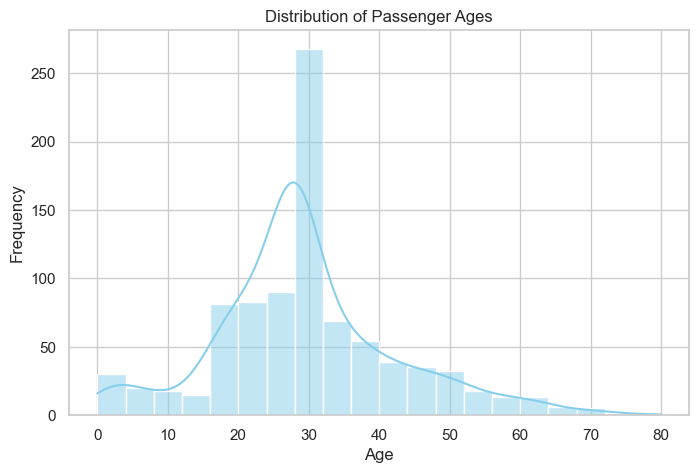

In [2]:
plt.figure(figsize=(8, 5))
sns.histplot(df["age"], bins=20, kde=True, color="skyblue")

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Frequency")

# Save and show
hist_path = os.path.join(output_dir, "age_histogram.png")
plt.savefig(hist_path, bbox_inches="tight")
plt.show()

**Interpretación:** 
El histograma muestra que la mayor concentración de pasajeros se encuentra entre los 20 y 30 años, en gran parte debido a la imputación de la mediana en los valores nulos, que acentúa este pico. Hay una cantidad considerable de niños pequeños (0-5 años) y la cantidad de pasajeros disminuye progresivamente conforme aumenta la edad.

### 2. Gráfico de barras de una variable categórica
Mostraremos la cantidad de pasajeros que sobrevivieron y los que no (`survived`).

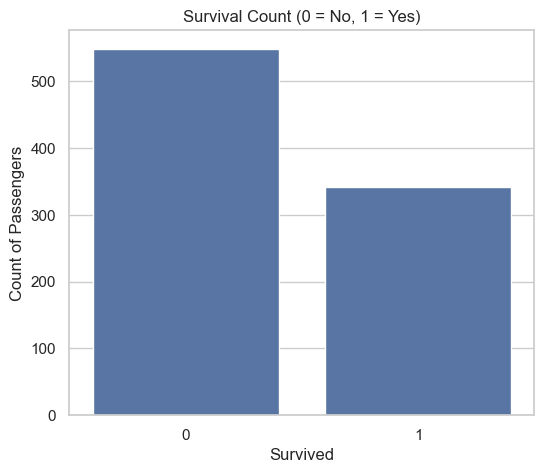

In [3]:
plt.figure(figsize=(6, 5))
# Create a countplot for the 'survived' column
sns.countplot(x="survived", data=df)

plt.title("Survival Count (0 = No, 1 = Yes)")
plt.xlabel("Survived")
plt.ylabel("Count of Passengers")

# Save and show
bar_path = os.path.join(output_dir, "survival_barchart.png")
plt.savefig(bar_path, bbox_inches="tight")
plt.show()

**Interpretación:** 
El gráfico de barras evidencia un desbalance en la variable objetivo: la cantidad de pasajeros que no sobrevivieron (0) es significativamente mayor a la de aquellos que sí sobrevivieron (1). Esto indica que la tragedia tuvo una alta tasa de mortalidad general.

### 3. Diagrama de dispersión de dos variables
Exploraremos la relación entre la edad de los pasajeros (`age`) y la tarifa que pagaron (`fare`).

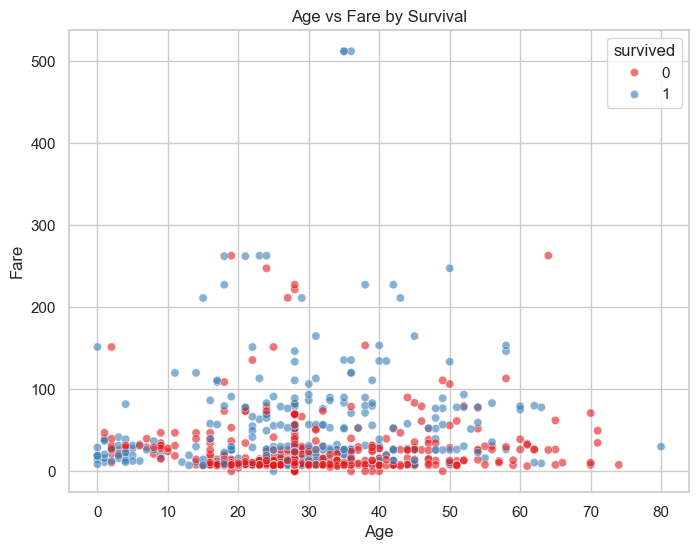

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="age", 
    y="fare", 
    hue="survived", 
    data=df, 
    alpha=0.6, 
    palette="Set1"
)

plt.title("Age vs Fare by Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

# Save and show
scatter_path = os.path.join(output_dir, "age_fare_scatter.png")
plt.savefig(scatter_path, bbox_inches="tight")
plt.show()

**Interpretación:** 
No se observa una correlación lineal clara entre la edad y la tarifa pagada (la mayoría de las tarifas son bajas en casi todas las edades). Sin embargo, se pueden notar algunos valores atípicos (tarifas superiores a 200 o 300) que en su gran mayoría corresponden a pasajeros que sobrevivieron (puntos azules o dependiendo del color del hue de supervivencia).

### 4. Mapa de calor de correlaciones
Visualizaremos cómo se relacionan entre sí las variables numéricas del dataset.

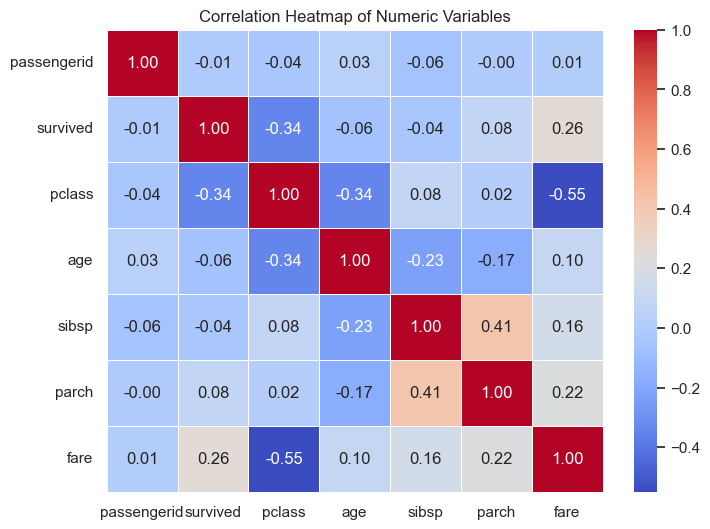

In [5]:
plt.figure(figsize=(8, 6))

# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=["number"])

# Calculate Pearson correlation
correlation_matrix = numeric_df.corr()

# Create heatmap
sns.heatmap(
    correlation_matrix, 
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f", 
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Variables")

# Save and show
heatmap_path = os.path.join(output_dir, "correlation_heatmap.png")
plt.savefig(heatmap_path, bbox_inches="tight")
plt.show()

**Interpretación:** 
El mapa de calor revela detalles interesantes:
- Hay una correlación negativa moderada entre la clase del pasajero (`pclass`) y la tarifa (`fare`), lo cual tiene sentido ya que una clase mejor (1) suele implicar una tarifa más alta.
- Existe una correlación negativa entre `pclass` y `age`, sugiriendo que los pasajeros de primera clase tienden a ser mayores que los de tercera clase.
- Las variables como `sibsp` (hermanos/esposos) y `parch` (padres/hijos) tienen una correlación positiva entre sí, indicando que las familias solían viajar juntas.